Contents:


# Exploratory Data Analysis: EIA Metadata

## Introduction

This notebook analyzes the U.S. Energy Information Administration (EIA) electricity metadata retrieved from the v2 API. The goal is to understand how time series are structured across datasets, frequencies, and facet dimensions to support downstream data exploration and analysis.

## Imports

In [49]:
%load_ext autoreload
%autoreload 2
import logging
import os
import io
import ast
from typing import Tuple, Dict

import helpers.hdbg as hdbg
import helpers.henv as henv
import helpers.hprint as hprint
import helpers.hs3 as hs3
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import causal_automl.eda_utils as caueduti

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Configure logger.
hdbg.init_logger(verbosity=logging.INFO)
_LOG = logging.getLogger(__name__)

# Configure the notebook style.
hprint.config_notebook()

# Configure S3.
s3_dir = "s3://causify-data-collaborators/causal_automl/metadata/"
aws_profile = "ck"

## Helper Functions

In [28]:
def get_missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a summary of missing value count and percentage per column.

    :param df: data to inspect
    :return: data with count and percentage of missing values
    """
    count = df.isna().sum()
    percent = df.isna().mean() * 100
    missing_count = pd.DataFrame({'Missing Count': count, 'Missing %': percent}).sort_values(by="Missing %", ascending=False)
    return missing_count

def plot_distribution(df_metadata: pd.DataFrame, column: str, title: str) -> None:
    """
    Plot a distribution count for a specified metadata column.

    :param df_metadata: metadata table containing time series fields
    :param column: column to group and count values by (e.g.,
        'frequency_id', 'data_units')
    :param title: title for the plot
    """
    if column not in df_metadata.columns:
        raise ValueError(f"Column '{column}' not found in df_metadata.")
    counts = df_metadata[column].value_counts()
    ax = counts.plot(kind="bar", figsize=(8, 4), title=title)
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Count")
    ax.grid(True)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Load and Preprocess Data

In [83]:
def _load_data(file_path: str, aws_profile:str) -> pd.DataFrame:
    """
    Load data from file path to a DataFrame.

    :param file_path: path of the data to load from
    :param aws_profile: AWS CLI profile used for access
    :return: DataFrame of the loaded data
    """
    file = hs3.from_file(file_path, aws_profile=aws_profile)
    df = pd.read_csv(io.StringIO(file))
    return df

def load_eia_metadata_and_parameters(
    s3_dir: str,
    metadata_file_path: str,
    parameter_subdir: str,
    aws_profile: str,
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Load EIA metadata and parameter files from S3.

    :param s3_dir: base S3 directory (e.g., "s3://mybucket/data/")
    :param metadata_file: metadata CSV filename (e.g., "eia_metadata.csv")
    :param parameter_subdir: subdirectory in `s3_dir` containing parameter files
    :param aws_profile: AWS CLI profile used for access
    :return: metadata and parameter DataFrames
    """
    # Load metadata CSV.
    metadata_path = os.path.join(s3_dir, metadata_file_path)
    df_metadata = _load_data(metadata_path, aws_profile)
    # Load all parameter CSVs.
    parameter_dir = os.path.join(s3_dir, parameter_subdir)
    s3fs_ = hs3.get_s3fs("ck")
    param_paths = s3fs_.ls(parameter_dir)
    param_dfs = {}
    for path in param_paths:
        if path.endswith(".csv"):
            key = os.path.basename(path).replace("_parameters.csv", "")
            full_path = f"s3://{path}"
            param_dfs[key] = _load_data(full_path, aws_profile)
    return df_metadata, param_dfs

def preprocess_eia(
    df_metadata: pd.DataFrame,
    param_dfs: Dict[str, pd.DataFrame],
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Preprocess metadata and parameter DataFrames for analysis.

    :param df_metadata: metadata index DataFrame
    :param param_dfs: parameter DataFrames
    :return: cleaned metadata and parameter DataFrames
    """
    # Preprocess metadata.
    df_metadata["frequency_id"] = df_metadata["frequency_id"].str.lower().str.strip()
    # Parse facets column if stored as string.
    df_metadata["facets"] = df_metadata["facets"].apply(ast.literal_eval)
    # Preprocess parameters.
    param_dfs_cleaned = {}
    for file_name, df_param in param_dfs.items():
        df_param_cleaned = df_param.copy()
        df_param_cleaned["facet_id"] = (
            df_param_cleaned["facet_id"].astype(str).str.strip().str.lower()
        )
        # Strip and clean id field in known affected file.
        df_param_cleaned["id"] = df_param_cleaned["id"].astype(str).str.strip()
        param_dfs_cleaned[file_name] = df_param_cleaned
    return df_metadata, param_dfs_cleaned

In [84]:
# Load EIA metadata index and parameters.
metadata_s3_path = f"eia_electricity_metadata_original_v1.0.csv"
param_s3_dir = f"eia_parameters_v1.0"
df_metadata, param_dfs = load_eia_metadata_and_parameters(s3_dir, metadata_s3_path, param_s3_dir, aws_profile)
# Preprocess EIA metadata index and parameters.
#df_metadata, param_dfs = preprocess_eia(df_metadata, param_dfs)

In [85]:
# Preview metadata.
print(df_metadata.shape)
print(df_metadata.columns)
df_metadata.head()

(172, 17)
Index(['url', 'id', 'dataset_id', 'name', 'description', 'frequency_id', 'frequency_alias', 'frequency_description', 'frequency_query', 'frequency_format', 'facets', 'data', 'data_alias', 'data_units', 'start_period', 'end_period', 'parameter_values_file'], dtype='object')


,url,id,dataset_id,name,description,frequency_id,frequency_alias,frequency_description,frequency_query,frequency_format,facets,data,data_alias,data_units,start_period,end_period,parameter_values_file
0,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_revenue,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",revenue,Revenue from Sales to Ultimate Customers,million dollars,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
1,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_sales,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",sales,Megawatt-hours Sold to Ultimate Customers,million kilowatt hours,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
2,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_price,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",price,Average Price of Electricity to Ultimate Custo...,cents per kilowatt-hour,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
3,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_customers,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",customers,Number of Ultimate Customers,number of customers,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
4,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_quarterly_revenue,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,quarterly,NaN,One data point every 3 months.,Q,"YYYY-""Q""Q","[{'id': 'stateid', 'description': 'State / Cen...",revenue,Revenue from Sales to Ultimate Customers,million dollars,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv


### EIA Metadata Index Column information

| **Column**              | **Description**                                                                 |
|-------------------------|---------------------------------------------------------------------------------|
| `url`                   | Full API URL to access the time series.                                         |
| `id`                    | Unique identifier for the time series.                                          |
| `dataset_id`            | Dataset group this series belongs to.                                           |
| `name`                  | Human-readable title of the time series.                                        |
| `description`           | Full description of what the time series measures.                              |
| `frequency_id`          | Frequency label (e.g. `monthly`, `quarterly`, `hourly`).                        |
| `frequency_alias`       | Alternative frequency name (often missing).                                     |
| `frequency_description` | Sentence-style explanation of frequency (e.g. "One data point for each month"). |
| `frequency_query`       | Query shorthand for frequency (e.g. `M` for monthly).                           |
| `frequency_format`      | Formatting string used in time index.                                           |
| `facets`                | JSON-style list of dimension fields used for the series.                        |
| `data`                  | Short name of the measured value (e.g. `revenue`, `sales`).                     |
| `data_alias`            | Human-readable version of the data name.                                        |
| `data_units`            | Units of measurement (e.g. `million dollars`, `cents per kWh`).                 |
| `start_period`          | Start date of available data (YYYY-MM format).                                  |
| `end_period`            | End date of available data (YYYY-MM format).                                    |
| `parameter_values_file` | S3 path to facet value mappings for this dataset.                               |


In [86]:
# Available parameter datasets.
print(param_dfs.keys())
# Preview one parameter file.
param_dfs["retail_sales"].head()

dict_keys(['capability', 'daily_fuel_type_data', 'daily_interchange_data', 'daily_region_data', 'daily_region_sub_ba_data', 'electric_power_operational_data', 'emissions_by_state_by_fuel', 'energy_efficiency', 'facility_fuel', 'fuel_type_data', 'interchange_data', 'meters', 'net_metering', 'operating_generator_capacity', 'region_data', 'region_sub_ba_data', 'retail_sales', 'source_disposition', 'summary'])


,dataset_id,facet_id,id,name,alias
0,retail_sales,stateid,IN,Indiana,(IN) Indiana
1,retail_sales,stateid,KS,Kansas,(KS) Kansas
2,retail_sales,stateid,MAT,Middle Atlantic,Region: (MAT) Middle Atlantic
3,retail_sales,stateid,CT,Connecticut,(CT) Connecticut
4,retail_sales,stateid,VA,Virginia,(VA) Virginia


### EIA Parameters Column information

| **Column**         | **Description**                                                                 |
|--------------------|---------------------------------------------------------------------------------|
| `dataset_id`       | Name of the parent dataset this parameter file belongs to (e.g. `retail_sales`). |
| `facet_id`         | The dimension or facet described (e.g. `stateid`, `sectorid`).                   |
| `id`               | The unique code or shorthand for the facet value (e.g. `CA`, `RES`).             |
| `name`             | Plain name of the facet value (e.g. `California`, `residential`).                |
| `alias`            | Display-friendly name or formatted version of the value.                |


## Introductory Analytics

### Missing Data

,Missing Count,Missing %
frequency_alias,164,95.348837
data_units,62,36.046512
data_alias,1,0.581395
url,0,0.000000
id,0,0.000000
description,0,0.000000
frequency_id,0,0.000000
name,0,0.000000
dataset_id,0,0.000000
frequency_query,0,0.000000


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Missing Values per Column'}, xlabel='Column', ylabel='Missing Count'>)

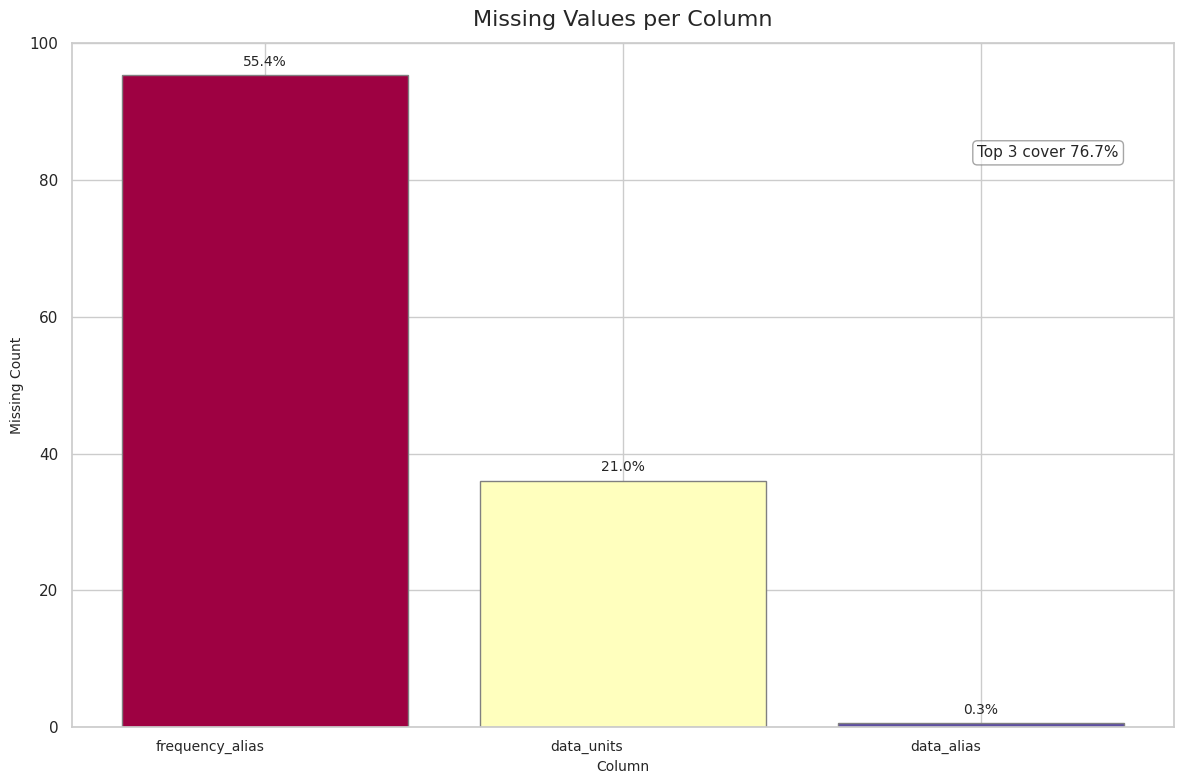

In [92]:
# Calculate missing counts and percentages.
missing_count = get_missing_summary(df_metadata)
display(missing_count)
# Plot percentage of missing value.
caueduti.plot_top_n_annotated_bar(
    counts=missing_pct,
    total=len(df_metadata),
    top_n=len(missing_pct),
    title="Missing Values per Column",
    xlabel="Column",
    ylabel="Missing Count",
    wrap_width=None,
    rotation=0,
)

Only three columns contain missing values: `frequency_alias`, `data_units`, and `data_alias`, accounting for 76.7% of all missing entries. The missing `frequency_alias` and `data_alias` are not essential, as they serve only as display-friendly labels. While `data_units` is more relevant for interpreting values (e.g., whether a series is in MW or MWh), it is often redundant with dataset context and not required for structural analysis.